# Block 2: Image Handling in Python

Welcome to the **Image Handling** session! In this notebook, you will learn how to work with images in Python — from understanding arrays to opening, inspecting, and displaying microscopy data.

## Learning Objectives

By the end of this session, you will be able to:

- Understand that images are arrays of numbers
- Create and manipulate arrays using NumPy (indexing, slicing, math)
- Understand multi-dimensional image data (2D, 3D, multi-channel, time-series)
- Open and inspect microscopy images using `tifffile` and `bioio`
- Display and compare images using `matplotlib`

In [37]:
from bioio import BioImage
import bioio_tifffile
import imageio.v3 as iio
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import cells3d
import tifffile

---

## 1. Arrays — The Building Blocks of Images

Before we work with images, we need to understand **arrays** — because in Python, every image is just an array of numbers.

### 1.1 From Lists to Arrays

Let's start with something familiar: Python lists.

In [ ]:
# A simple list of numbers — think of it as a row of pixel values
row = [0, 50, 100, 150, 200, 255]
print(row)
print(type(row))

In [ ]:
# A list of lists — this is like a tiny 2D image!
grid = [
    [0, 0, 0, 0, 0],
    [0, 255, 255, 255, 0],
    [0, 255, 0, 255, 0],
    [0, 255, 255, 255, 0],
    [0, 0, 0, 0, 0],
]
print(grid)
print(f"Number of rows: {len(grid)}")
print(f"Number of columns: {len(grid[0])}")

In [ ]:
# A list of lists of lists — this is like a tiny 3D image (e.g. RGB)!
rgb_list = [
    [[255, 0, 0], [255, 0, 0], [255, 0, 0]],
    [[0, 255, 0], [0, 255, 0], [0, 255, 0]],
    [[0, 0, 255], [0, 0, 255], [0, 0, 255]],
]
print(rgb_list)
print(f"Number of rows: {len(rgb_list)}")
print(f"Number of columns: {len(rgb_list[0])}")
print(f"Number of channels: {len(rgb_list[0][0])}")

This works, but Python lists are **slow** and **inconvenient** for numerical work. This is where **NumPy** comes in.

### 1.2 NumPy Arrays

[NumPy](https://numpy.org/) is the fundamental library for numerical computing in Python. It provides the `ndarray` — a fast, memory-efficient multi-dimensional array.

In [ ]:
# Convert our list-of-lists into a NumPy array
image = np.array(grid)
print(image)
print(f"Shape: {image.shape}")  # (rows, columns)
print(f"Data type: {image.dtype}")  # integer type
print(f"Min: {image.min()}, Max: {image.max()}")

**Key properties of a NumPy array:**

| Property | Meaning | Example |
|----------|---------|----------|
| `.shape` | Dimensions (rows, cols, ...) | `(5, 5)` |
| `.dtype` | Data type of elements | `int64`, `uint8`, `float64` |
| `.ndim` | Number of dimensions | `2` |
| `.size` | Total number of elements | `25` |
| `.min()`, `.max()` | Value range | `0`, `255` |

### 1.3 Creating Arrays

NumPy provides handy functions to create arrays without typing every value:

In [ ]:
# All zeros — like a black image
black = np.zeros((4, 6), dtype=np.uint8)
print("Zeros (black image):")
print(black)

# All ones (multiplied by 255) — like a white image
white = np.ones((4, 6), dtype=np.uint8) * 255
print("\nOnes * 255 (white image):")
print(white)

# Random values — like noise
noise = np.random.randint(0, 256, size=(4, 6), dtype=np.uint8)
print("\nRandom (noise):")
print(noise)

### 1.4 Indexing and Slicing

We access elements in an array using **indexing** (single element) and **slicing** (sub-regions).

```
array[row, col]           # single element
array[start:stop, :]      # row range, all columns
array[:, start:stop]      # all rows, column range
array[r1:r2, c1:c2]      # sub-region
```

**Remember:** Python is **0-indexed** and slices are **exclusive** of the stop value.

In [ ]:
# Let's use our 5x5 image from before
print("Full image:")
print(image)

In [ ]:
# Access a single pixel (row 2, column 2)
print(f"Pixel at [2, 2]: {image[2, 2]}")

In [ ]:
# Get a row
print(f"Row 1: {image[1, :]}")

In [ ]:
# Get a column
print(f"Column 3: {image[:, 3]}")

In [ ]:
# Get a sub-region (the inner 3x3 block)
print(f"Inner 3x3 block (rows 1-3, cols 1-3):")
print(image[1:4, 1:4])

### 1.5 Simple Array Math

NumPy lets you do math on entire arrays at once — no loops needed!

In [ ]:
a = np.array([[10, 20], [30, 40]])
b = np.array([[1, 2], [3, 4]])
print(a)
print(b)

In [41]:
print("a + b =")
print(a + b)

print("\na - b =")
print(a - b)

a + b =
[[11 22]
 [33 44]]

a - b =
[[ 9 18]
 [27 36]]


In [ ]:
print("a * 2 =")
print(a * 2)

print("\na * b =")
print(a * b)

print("\na / 2 =")
print(a / 2)

Simple arithmetic operations are done **element-wise**

⚠️ **Watch out for overflow!** With `uint8` (0–255), values wrap around:

In [ ]:
# Careful with uint8 overflow
x = np.array([200, 250])
print(f"x: {x}")
print(f"x + 100 = {x + 100}")  # 200+100=300 → wraps to 44!

In [ ]:
x = np.array([200, 250], dtype=np.uint8)
print(f"x: {x}")
print(f"x + 100 = {x + np.uint8(100)}")  # 200+100=300 → wraps to 44!

In [ ]:
# Use np.clip to avoid this
result = np.clip(x.astype(np.int16) + 100, 0, 255).astype(np.uint8)
print(f"Clipped: {result}")  # Correctly capped at 255

---

### ✏️ Try It Yourself — Arrays

1. Create a 6×6 array of zeros (dtype `uint8`)
2. Set the center 2×2 pixels to 128
3. Set the corner pixels (all four) to 255
4. Print the array, its shape, and its min/max values

In [ ]:
# ✏️ Your code here

### Solution 1

````{admonition} Solution
:class: dropdown

```python
# 1. Create 6x6 zeros
arr = np.zeros((6, 6), dtype=np.uint8)

# 2. Center 2x2 pixels to 128
arr[2:4, 2:4] = 128

# 3. Corner pixels to 255
arr[0, 0] = 255
arr[0, 5] = 255
arr[5, 0] = 255
arr[5, 5] = 255

# 4. Print
print(arr)
print(f"Shape: {arr.shape}")
print(f"Min: {arr.min()}, Max: {arr.max()}")
```
````

---

## 2. Images Are Arrays

Now that we understand arrays, let's connect this to images.  
An image is nothing more than an array of numbers, where each number represents a pixel intensity.

### 2.1 A First Look: Displaying an Array as an Image

In [ ]:
print(image)

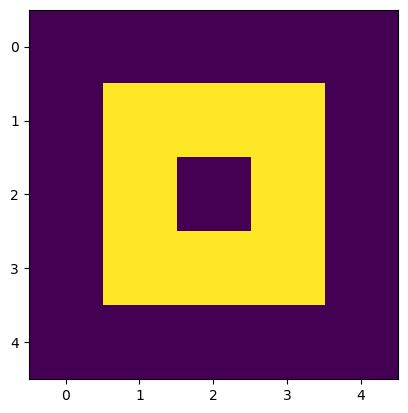

In [43]:
# Our 5x5 "image" from earlier
plt.imshow(image)

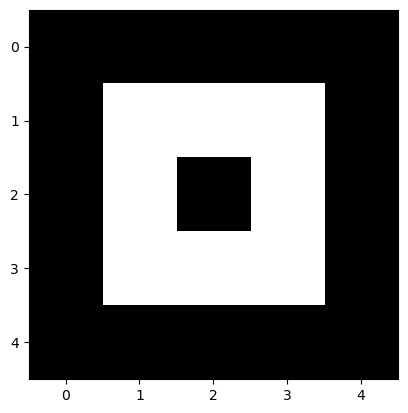

In [44]:
# Our 5x5 "image" from earlier
plt.imshow(image, cmap="grey")

### 2.2 Understanding Dimensions


Images can have different numbers of dimensions depending on what they represent:

| Dimensions | Shape | What it represents |
|-----------|-------|--------------------|
| 2D | `(Y, X)` | Single grayscale image |
| 3D | `(Z, Y, X)` | Z-stack (3D volume) |
| 3D | `(Y, X, 3)` | RGB color image |
| 4D | `(Z, C, Y, X)` | Z-stack with multiple channels |
| 5D | `(T, Z, C, Y, X)` | Time-lapse of multi-channel z-stacks |

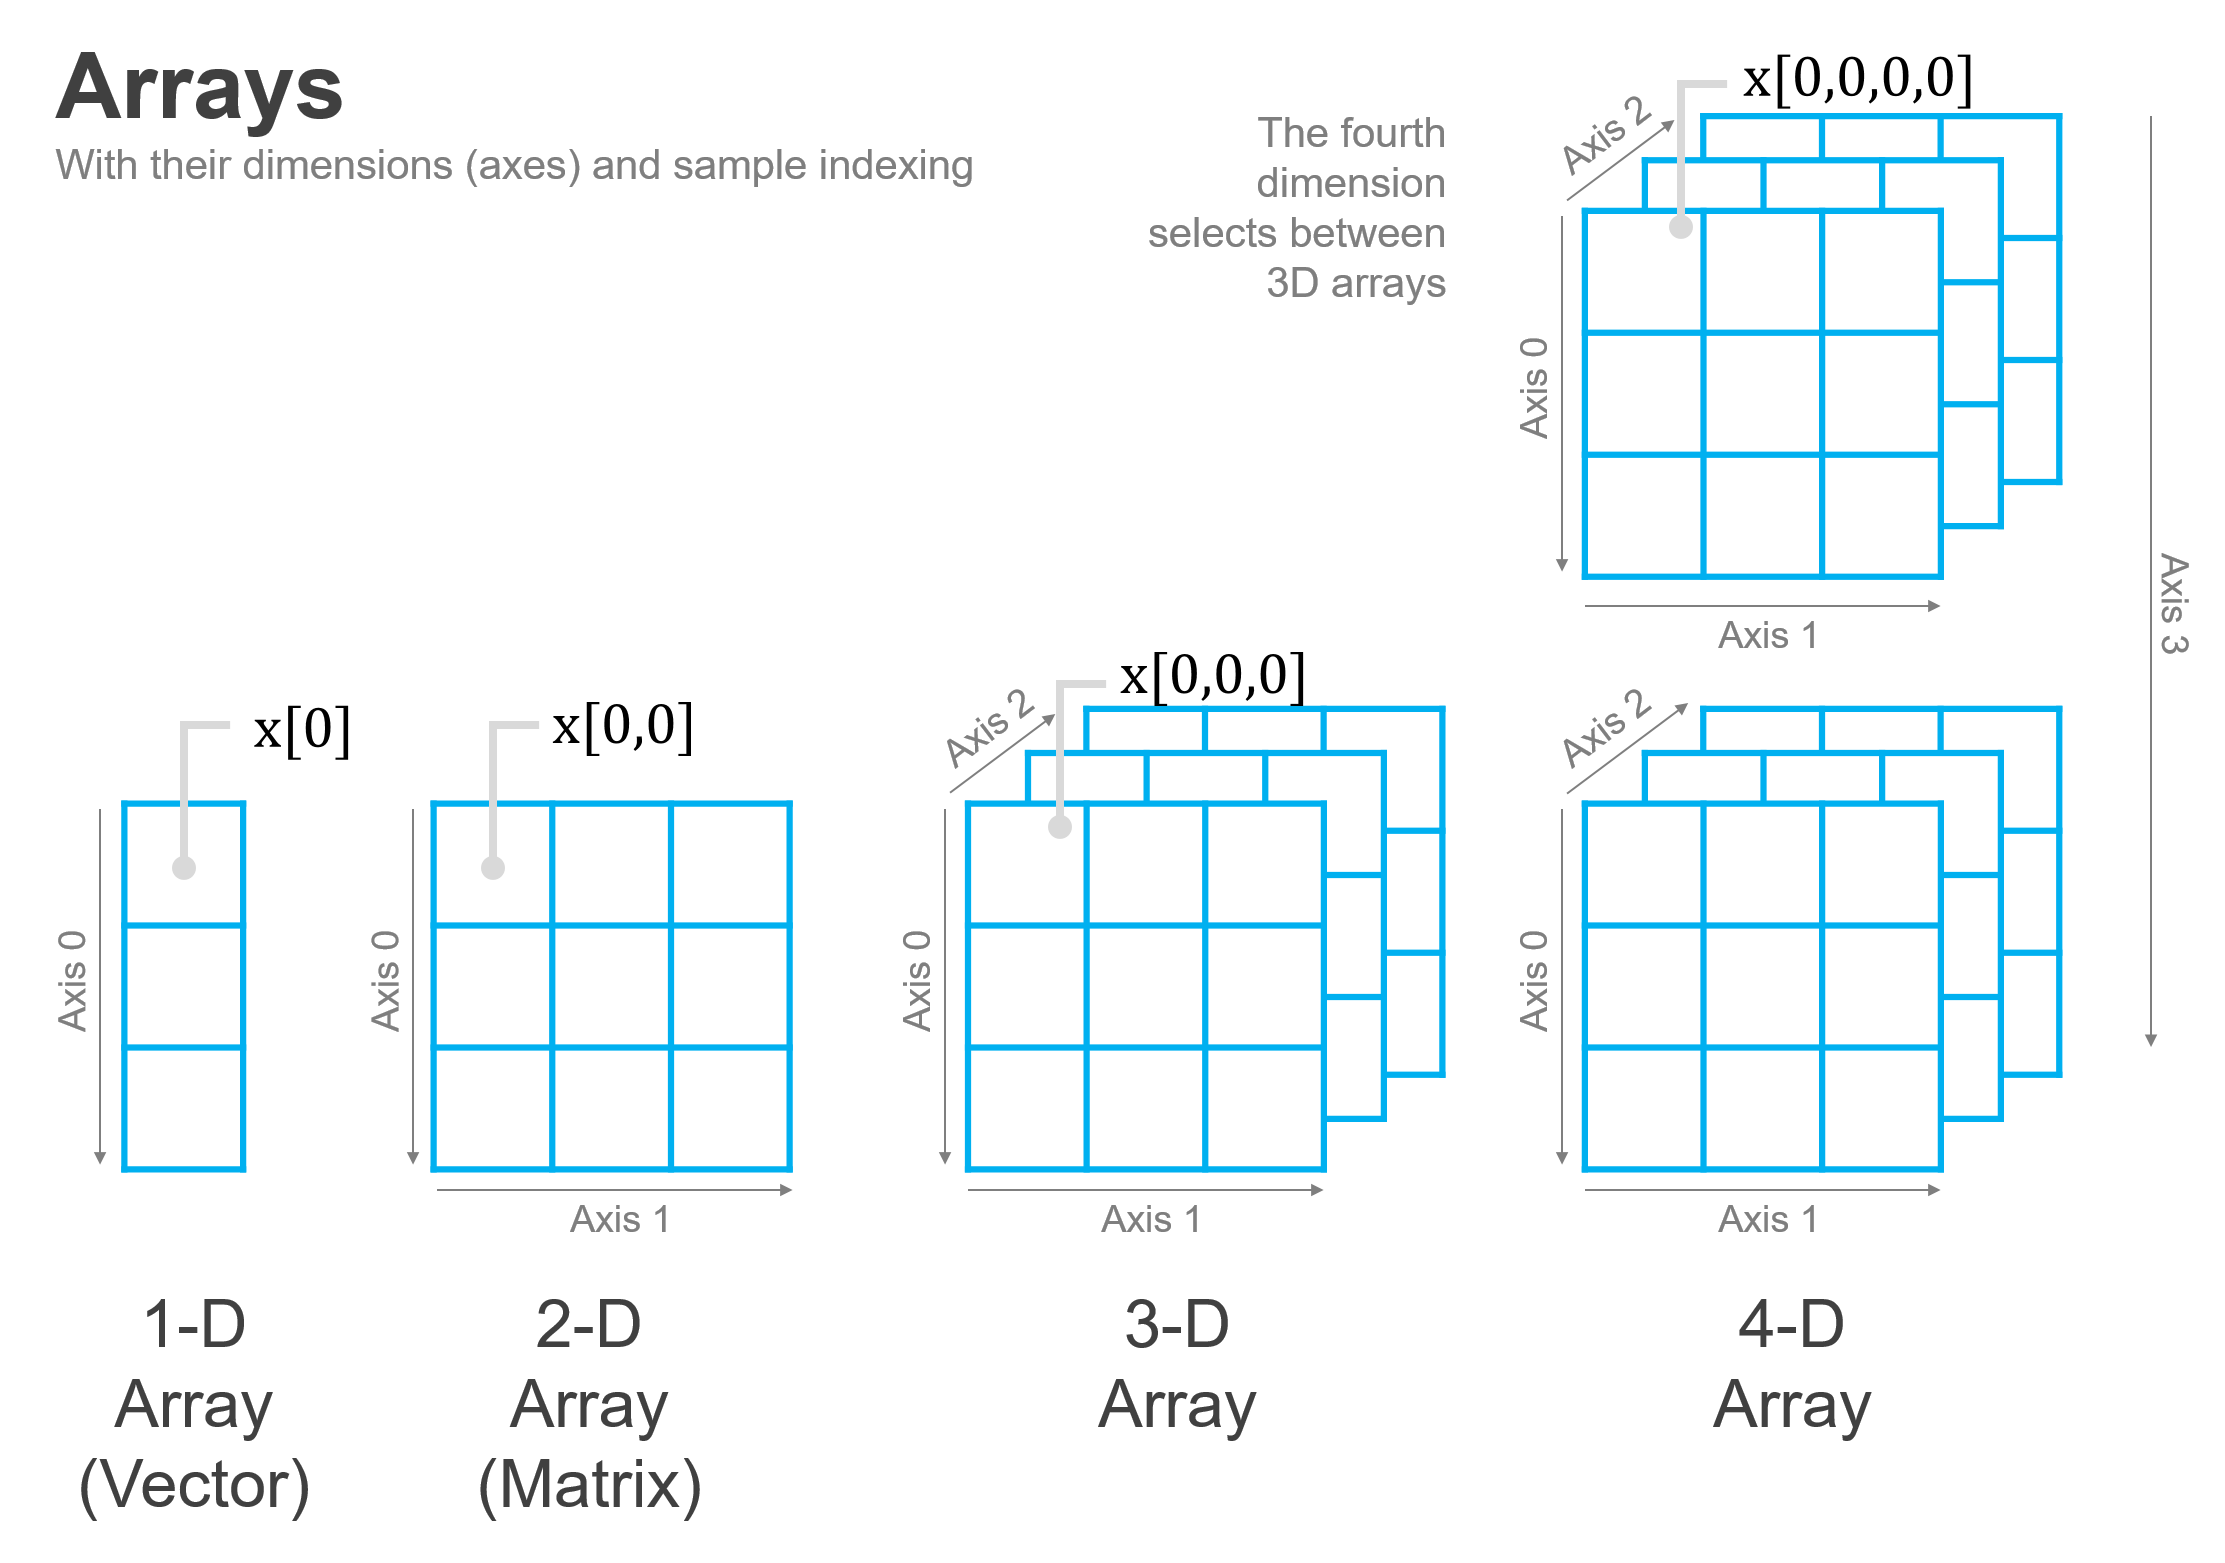

### 2.3 A Real Image

Let's load a real microscopy dataset. We'll use `cells3d()` from `scikit-image` — a 3D fluorescence microscopy image of cells with **two channels** (nuclei and membranes) - and create some slices to see how each of these looks:

In [ ]:
# Load the cells3d dataset
data = cells3d()  # shape: (Z, C, Y, X)

print(f"Shape: {data.shape}")
print(f"Dimensions: (Z-slices, Channels, Height, Width)")
print(f"Data type: {data.dtype}")
print(f"Value range: {data.min()} - {data.max()}")

In [ ]:
# Extract a single 2D slice: middle z-slice, channel 0 (membranes)
z_mid = data.shape[0] // 2  # 60 / 2 = 30
slice_2d = data[z_mid, 0, :, :]  # Z=30, Channel=0, all Y, all X

print(f"2D slice shape: {slice_2d.shape}")
print(f"Data type: {slice_2d.dtype}")

plt.imshow(slice_2d, cmap="viridis")

In [ ]:
# 2D — a simple grayscale image (from our real data)
img_2d = data[z_mid, 1, :, :]  # nuclei channel
print(f"2D image: {img_2d.shape} → (Y, X)")
plt.imshow(img_2d, cmap="gray")

In [ ]:
# 3D — a z-stack (all slices, one channel)
img_3d = data[:, 1, :, :]  # all Z, nuclei channel
print(f"3D stack: {img_3d.shape} → (Z, Y, X)")

# RGB — create a fake RGB from our channels
img_rgb = np.zeros((256, 256, 3), dtype=np.uint16)
img_rgb[:, :, 1] = data[z_mid, 0, :, :]  # membranes → green
img_rgb[:, :, 2] = data[z_mid, 1, :, :]  # nuclei → blue
print(f"RGB image: {img_rgb.shape} → (Y, X, C)")

# Time-series — create a fake time-series by repeating z-slices
img_time = np.stack([data[i * 6, 1, :, :] for i in range(10)])
print(f"Time-series: {img_time.shape} → (T, Y, X)")

### 2.4 Interactive Exploration — Browsing a Z-Stack

Let's use an interactive slider to browse through the z-slices:

In [ ]:
from ipywidgets import interact, IntSlider, Output
from IPython.display import clear_output

nuclei_stack = data[:, 1, :, :]  # all Z, nuclei channel

out = Output()


def browse_z(z=0):
    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(nuclei_stack[z], cmap="gray")
        ax.set_title(f"Nuclei — Z-slice {z}/{nuclei_stack.shape[0] - 1}")
        plt.show()


display(out)
interact(browse_z, z=IntSlider(min=0, max=nuclei_stack.shape[0] - 1, step=1, value=0));


---

### ✏️ Try It Yourself — Images as Arrays

Using the `data` array (shape: `(Z, C, Y, X)`):

1. Extract the **25th** z-slice of the **membrane** channel (channel 0)
2. Print its shape and data type
3. Display it using `plt.imshow()` with a colormap of your choice
   (hint: try `"magma"`, `"viridis"`, or `"inferno"`)
4. What is the mean pixel intensity of this slice? (hint: `.mean()` on the slice)

In [ ]:
# ✏️ Your code here

### Solution 2

````{admonition} Solution
:class: dropdown

```python
# 1. First z-slice, membrane channel
membrane_first = data[25, 0, :, :]

# 2. Print info
print(f"Shape: {membrane_first.shape}")
print(f"Data type: {membrane_first.dtype}")

# 3. Display
plt.figure(figsize=(5, 5))
plt.imshow(membrane_first, cmap="magma")
plt.title("Membranes — Z-slice 25")
plt.colorbar(shrink=0.8)
plt.show()

# 4. Mean intensity
print(f"Mean intensity: {membrane_first.mean():.2f}")
```
````

---

## 3. Opening Images with Python

In research, you rarely create images from scratch — you open files from your microscope. Let's learn how to do that properly.

### 3.1 Saving a Test Image

First, let's save our `cells3d` data as a TIFF file so we can practice opening it:

In [ ]:
# Save the nuclei z-stack as a TIFF file
nuclei_stack = data[:, 1, :, :]
tifffile.imwrite("./data/nuclei_stack.tif", nuclei_stack)

# Save a single 2D slice
tifffile.imwrite("./data/nuclei_slice.tif", data[z_mid, 1, :, :])

print("Saved: nuclei_stack.tif and nuclei_slice.tif")

### 3.2 Opening Images with `tifffile`

[tifffile](https://github.com/cgohlke/tifffile) is a fast and reliable library for reading and writing TIFF files — the most common format in microscopy.

In [ ]:
# Simple: read directly into a NumPy array
img_stack = tifffile.imread("./data/nuclei_stack.tif")
img_slice = tifffile.imread("./data/nuclei_slice.tif")

In [ ]:
print(f"Shape: {img_stack.shape}")
print(f"Data type: {img_stack.dtype}")
plt.imshow(img_slice)

In [ ]:
# More control: use TiffFile for metadata and lazy reading
with tifffile.TiffFile("./data/nuclei_stack.tif") as tif:
    print(f"Number of pages (slices): {len(tif.pages)}")
    print(f"Image shape: {tif.pages[0].shape}")
    print(f"Data type: {tif.pages[0].dtype}")

    # Read just one slice (memory-efficient for large files)
    single_page = tif.pages[0].asarray()
    print(f"\nFirst page shape: {single_page.shape}")

💡 **Why `with ... as`?** The `with` statement (a *context manager*) ensures the file is properly closed after use, even if an error occurs. This is good practice for any file operation.

### 3.3 Opening Images with `bioio`

[BioIO](https://github.com/bioio-devs/bioio) is a more versatile library that understands many microscopy file formats and their metadata. It gives you labeled dimensions (T, C, Z, Y, X) out of the box.

In [49]:
# Need to import plugins manually for different data types, e.g. TIFF:
# import bioio_tifffile

# Open with BioIO
bio_img = BioImage("./data/nuclei_stack.tif")

print(f"Shape (labeled): {bio_img.dims}")
print(f"Shape (raw):     {bio_img.shape}")
print(f"Data type:       {bio_img.dtype}")
print(f"\nDimension order: {bio_img.dims.order}")

# Access the image data as a NumPy array
bio_data = bio_img.data
print(f"\nNumPy array shape: {bio_data.shape}")

Shape (labeled): <Dimensions [T: 1, C: 1, Z: 60, Y: 256, X: 256]>
Shape (raw):     (1, 1, 60, 256, 256)
Data type:       uint16

Dimension order: TCZYX

NumPy array shape: (1, 1, 60, 256, 256)


### 3.4 `tifffile` vs `bioio` — When to Use Which?

| Feature | `tifffile` | `bioio` |
|---------|-----------|--------|
| Speed | ⚡ Very fast | Slightly slower |
| TIFF support | Excellent | Via plugins |
| Other formats (CZI, ND2, ...) | ❌ | ✅ (with plugins) |
| Labeled dimensions (T, C, Z, Y, X) | ❌ | ✅ |
| Metadata access | Basic | Rich |
| Best for | Quick TIFF reading | Multi-format workflows |

**Rule of thumb:** Use `tifffile` for quick TIFF work, `bioio` when you need format flexibility or labeled dimensions.

```{admonition} 🔍 Further Methods — How Professionals Open Images
:class: tip

In real-world pipelines, you'll often encounter:

- **`bioio` with plugins** like `bioio-czi` (Zeiss), `bioio-nd2` (Nikon), `bioio-lif` (Leica) for vendor-specific formats
- **`dask` arrays** via `bioio` for images too large to fit in memory (lazy loading)
- **`napari`** for interactive multi-dimensional image viewing
- **`ome-zarr`** for cloud-optimized storage of large datasets

We won't cover these today, but they build on the same concepts you're learning now!
```

---

## 4. Displaying and Comparing Images with Matplotlib

In research, you often need to display multiple images side by side — different channels, conditions, or processing steps. `matplotlib` makes this easy with **subplots**.

### 4.1 Single Image with Proper Labels

In [ ]:
nuclei_mid = data[z_mid, 1, :, :]
plt.imshow(nuclei_mid)

In [ ]:
plt.imshow(nuclei_mid, cmap="gray")
plt.title("Nuclei") # add a title
plt.xlabel("X (pixels)") # add an axis label
plt.colorbar(label="Intensity") # add a colourbar
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

#### Directly adapting the plot has its limits. Therefore we make use of the image object itself 

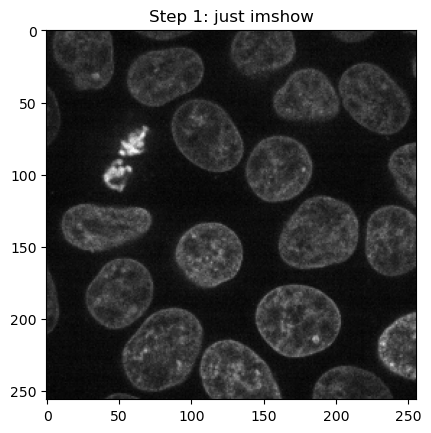

In [52]:
# Step 1: bare image — no labels at all
fig, ax = plt.subplots()
ax.imshow(nuclei_mid, cmap="gray")
ax.set_title("Step 1: just imshow")
plt.show()

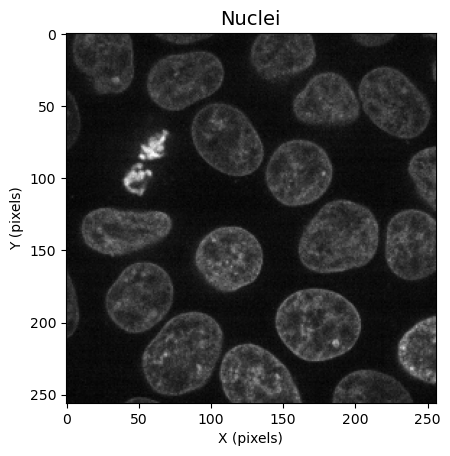

In [53]:
# Step 2: add a title and axis labels
fig, ax = plt.subplots()
ax.imshow(nuclei_mid, cmap="gray")
ax.set_title("Nuclei", fontsize=14)
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
plt.show()

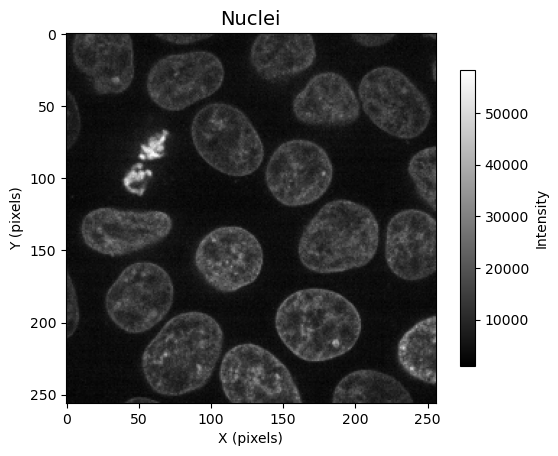

In [56]:
# Step 3: add a colourbar to show the intensity scale
fig, ax = plt.subplots()
im = ax.imshow(nuclei_mid, cmap="gray")
ax.set_title("Nuclei", fontsize=14)
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Intensity")
plt.show()

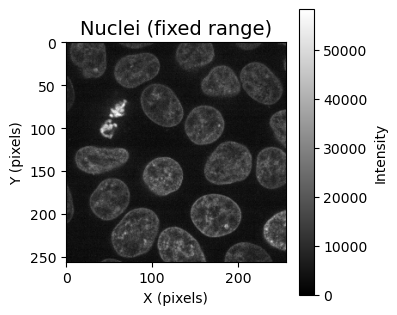

In [57]:
# Step 4: fix the display range with vmin/vmax for consistent scaling. Set figure size
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(nuclei_mid, cmap="gray", vmin=0, vmax=nuclei_mid.max())
ax.set_title("Nuclei (fixed range)", fontsize=14)
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Intensity")
plt.tight_layout()
plt.show()

### 4.2 Side-by-Side Comparison (Subplots)
Sometimes we want to see more than one image at a time. Subplots let us do this in a clean, organized way.

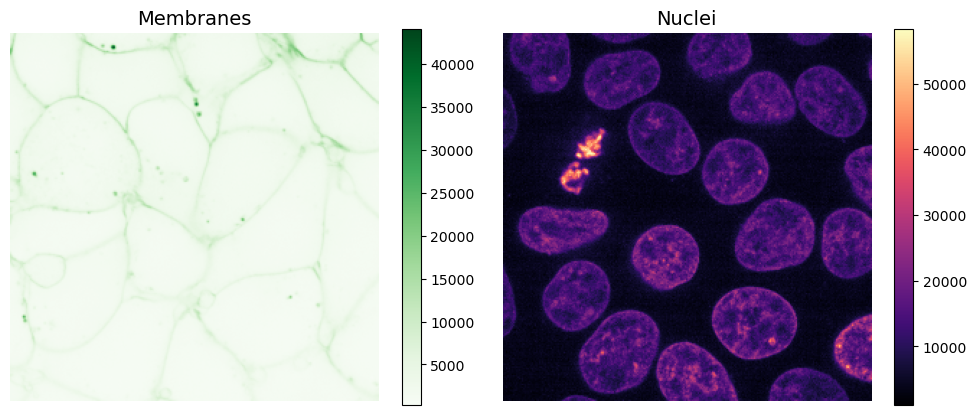

In [58]:
membranes_mid = data[z_mid, 0, :, :]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: Membranes
im0 = axes[0].imshow(membranes_mid, cmap="Greens")
axes[0].set_title("Membranes", fontsize=14)
axes[0].set_xlabel("X (pixels)")
axes[0].set_ylabel("Y (pixels)")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Right: Nuclei
im1 = axes[1].imshow(nuclei_mid, cmap="magma")
axes[1].set_title("Nuclei", fontsize=14)
axes[1].set_xlabel("X (pixels)")
axes[1].set_ylabel("Y (pixels)")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

### Overlay images to see multiple channels at once

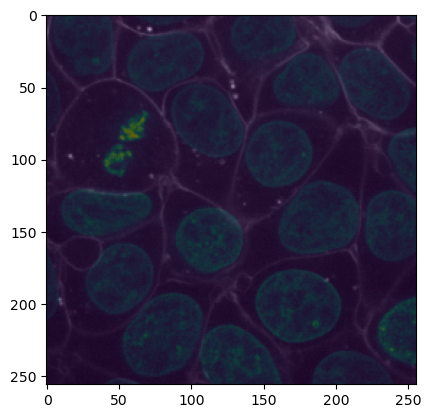

In [64]:
fig, ax = plt.subplots()
ax.imshow(membranes_mid, cmap="grey")
ax.imshow(nuclei_mid, cmap="viridis", alpha=0.4)
plt.show()

### 4.3 RGB example

In [65]:
rgb = iio.imread("./data/rgb.jpg")
rgb.shape

(2048, 2048, 3)

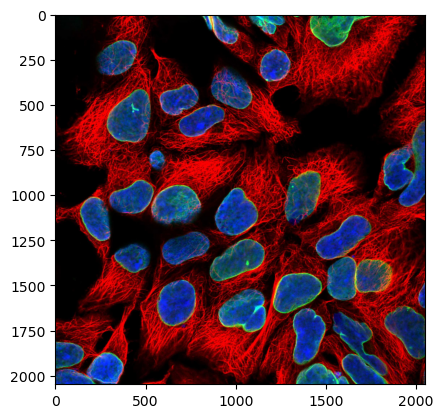

In [66]:
plt.imshow(rgb)

```{admonition} 🔍 Further Methods — Publication-Quality Figures
:class: tip

For real publications, you'll want to:

- Add **scale bars** instead of pixel axes (see `matplotlib-scalebar` or `napari`)
- Use **consistent intensity scaling** across panels (`vmin`, `vmax`)
- Save as **vector graphics** (`.svg`, `.pdf`) using `plt.savefig("fig.svg", dpi=300)`
- Use **seaborn** or custom stylesheets for consistent aesthetics
```

---

### ✏️ Try It Yourself — Matplotlib

1. Create a figure with **3 subplots** in a row
2. Display 3 different channels of the RGB image or different z-slices of the nuclei channel (e.g., z=10, z=30, z=50)
3. Add a title to each panel showing the z-slice number
4. Turn off the axes
5. Add an overall title using `plt.suptitle()`

In [ ]:
# ✏️ Your code here

### Solution 3

````{admonition} Solution
:class: dropdown

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb[:, :, 0], cmap="Reds")
axes[0].set_title("Red channel")
axes[0].axis("off")

axes[1].imshow(rgb[:, :, 1], cmap="Greens")
axes[1].set_title("Green channel")
axes[1].axis("off")

axes[2].imshow(rgb[:, :, 2], cmap="Blues")
axes[2].set_title("Blue channel")
axes[2].axis("off")

plt.suptitle("RGB channels", fontsize=16)
plt.tight_layout()
plt.show()
```
````

---

## 5. 🧪 Mini-Project: Image Juxtaposition

Time to put it all together! In this mini-project, you will:

1. Open the saved `nuclei_stack.tif` file using `tifffile`
2. Also load the full `cells3d()` dataset to get the membrane channel
3. Select a z-slice of your choice
4. Create a **side-by-side figure** with:
   - **Left panel:** Membrane channel with a `"green"` colormap
   - **Right panel:** Nuclei channel with a `"magma"` colormap
   - Proper titles, a colorbar for each panel, and an overall title
5. **Bonus:** Add a third panel showing a simple overlay (add both channels together)

Use the code snippets from above as building blocks!

In [ ]:
# 🧪 Your mini-project code here

### Solution Mini-project

````{admonition} Solution
:class: dropdown

```python
# 1. Open the nuclei stack
nuclei = tifffile.imread("nuclei_stack.tif")

# 2. Load the full dataset for membranes
full_data = cells3d()
membranes = full_data[:, 0, :, :]  # all Z, channel 0

# 3. Pick a z-slice
z = 30

# 4. Side-by-side figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Membranes
im0 = axes[0].imshow(membranes[z], cmap="green")
axes[0].set_title("Membranes")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Nuclei
im1 = axes[1].imshow(nuclei[z], cmap="magma")
axes[1].set_title("Nuclei")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

# 5. Bonus: Overlay (add both, clip to avoid overflow)
overlay = np.clip(
    membranes[z].astype(np.float64) + nuclei[z].astype(np.float64),
    0, 65535
).astype(np.uint16)
im2 = axes[2].imshow(overlay, cmap="gray")
axes[2].set_title("Overlay")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.axis("off")

plt.suptitle(f"cells3d — Z-slice {z}", fontsize=16)
plt.tight_layout()
plt.show()
```
````

---

## 6. Recap & Further Reading

### What You Learned Today

| Concept | Key Takeaway |
|---------|-------------|
| **Arrays** | Images are NumPy arrays; use `.shape`, `.dtype`, `.min()`, `.max()` |
| **Indexing/Slicing** | `array[row, col]` for pixels, `array[start:stop]` for regions |
| **Dimensions** | 2D (grayscale), 3D (z-stack/RGB), 4D+ (channels, time) |
| **`tifffile`** | Fast TIFF reading with `imread()` / `TiffFile` context manager |
| **`bioio`** | Multi-format reader with labeled dimensions |
| **`matplotlib`** | `imshow()`, colormaps, subplots, titles, colorbars |

### Further Reading & Resources

- 📖 [NumPy for Absolute Beginners](https://numpy.org/doc/stable/user/absolute_beginners.html)
- 📖 [The BioImage Book](https://bioimagebook.github.io/) — Comprehensive guide to bio-image analysis
- 📖 [Matplotlib Image Tutorial](https://matplotlib.org/stable/tutorials/images.html)
- 📖 [tifffile documentation](https://github.com/cgohlke/tifffile)
- 📖 [BioIO documentation](https://github.com/bioio-devs/bioio)
- 📖 [napari](https://napari.org/) — Interactive multi-dimensional image viewer for Python
- 📖 [OME-ZARR / NGFF](https://ngff.openmicroscopy.org/) — Next-generation file formats for bioimaging
- 📖 [Python Introduction - Automate the boring stuff](https://automatetheboringstuff.com/)

---

### Cleanup

Remove the temporary TIFF files we created during this session:

In [ ]:
import os

for f in ["./data/nuclei_stack.tif", "./data/nuclei_slice.tif"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"Removed {f}")